In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import string
from input.plot_styles import family_colors, set_plot_style, model_order, FULL_WIDTH, HALF_WIDTH, GOLDEN_RATIO

In [2]:
model_dict = {"qwen8":"Qwen/Qwen3-8B",
             "qwen14": "Qwen/Qwen3-14B",
             "gemma12": "google/gemma-3-12b-it",
             "gemma27": "google/gemma-3-27b-it",
             "llama8": "meta-llama/Llama-3.1-8B-Instruct",
             "ministral14": "mistralai/Ministral-3-14B-Instruct-2512",
             "ministral8": "mistralai/Ministral-3-8B-Instruct-2512"}

In [5]:
set_plot_style()

### Loading data

In [3]:
def load_results_to_dict(rule):
    
    directory = f"results/benchmark/{rule}"
    
    df_dict = {}
    
    # Check if directory exists
    if not os.path.exists(directory):
        print(f"Directory {directory} not found.")
        return df_dict

    # Iterate through files in the folder
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            # Extract model name from filename (e.g., 'answers_choose5_llama8.csv')
            # split by '_' and use the last part without '.csv'
            model_name = filename.split('_')[-1].replace('.csv', '')
            
            # Load the dataframe
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path)
            df_dict[model_name] = df[sorted(df.columns, key=lambda x: int(x))]
            
            print(f"✓ Loaded {model_name}")

    ordered_dict = {k: df_dict[k] for k in model_order[::-1] if k in df_dict}
            
    return ordered_dict

In [4]:
df_dict_bystander = load_results_to_dict("bystander")
df_dict_busy = load_results_to_dict("busy")
df_dict_specy = load_results_to_dict("specy")
df_dict_specy_reverse = load_results_to_dict("specy_reverse")

✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8
✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8
✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8
✓ Loaded qwen8
✓ Loaded qwen14
✓ Loaded gemma12
✓ Loaded gemma27
✓ Loaded llama8
✓ Loaded ministral14
✓ Loaded ministral8


### Plotting results

In [41]:
def process_and_plot_together(df_dict, color_map, rule, title=None, ylabel = True):
    fig, ax = plt.subplots(figsize=(3.2, 3.5*0.7))
    
    n_models = len(df_dict)
    x = np.array([0, 1])
    offsets = np.linspace(-0.2, 0.2, n_models)
    
    for i, (model_name, df) in enumerate(df_dict.items()):
        means = df.mean(axis=0).values
        se = df.sem(axis=0).values
        color = color_map.get(model_name, "gray")
        
        ax.errorbar(
            x + offsets[i],
            means,
            yerr=se,
            fmt='o',
            ms=3,
            color=color,
            linewidth=1.5,
            capsize=3,
            capthick=1,
            label=model_name,
            zorder=3
        )
        ax.plot(
            x + offsets[i],
            means,
            linestyle='-',
            color=color,
            linewidth=1.5,
            alpha=0.5,
            zorder=2
        )

    # Reference line at perfect performance
    ax.axhline(y=1.0, color='r', linestyle='--', linewidth=1)
    
    # Match your exact tick/label styling
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Correct answer: Yes', 'Correct answer: No'], fontsize=10)
    if ylabel:
        ax.set_ylabel(r'$P(\mathrm{correct})$', fontsize=10, labelpad=8)
    else:
        ax.set_ylabel(r' * ', fontsize=10, labelpad=8, c = "white")
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.5, 1.5)
    plt.yticks(fontsize=10)
    plt.xticks(fontsize=10)
    
    ax.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(f"plots/benchmark/{rule}.pdf")
    plt.show()

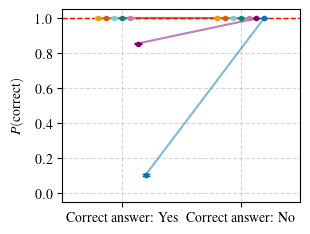

In [42]:
process_and_plot_together(df_dict_busy, family_colors, "busy")

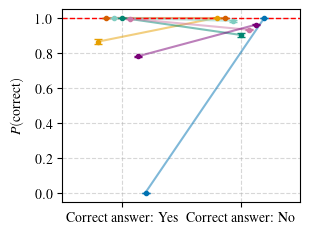

In [43]:
process_and_plot_together(df_dict_bystander, family_colors, "bystander", False)

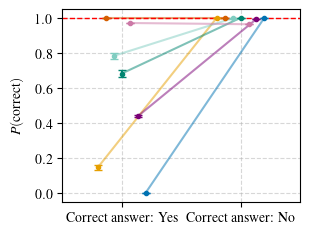

In [44]:
process_and_plot_together(df_dict_specy, family_colors, "specy")

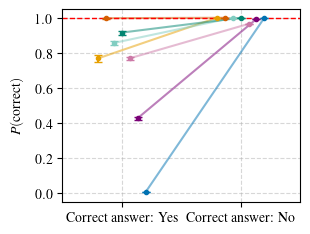

In [45]:
process_and_plot_together(df_dict_specy_reverse, family_colors,"specy reverse", False)

In [49]:
def plot_summary_scores(df_dict_bystander, df_dict_busy, df_dict_specy, df_dict_specy_reverse, color_map):
    
    benchmark_dicts = {
        "Bystander": df_dict_bystander,
        "Busy": df_dict_busy,
        "Specy": df_dict_specy,
        "Specy Reverse": df_dict_specy_reverse,
    }
    
    # Compute scores per model averaged across all benchmarks
    records = {model: {"Overall": [], "Correct Yes": [], "Correct No": []} 
               for model in color_map.keys()}
    
    for benchmark_name, df_dict in benchmark_dicts.items():
        for model_name, df in df_dict.items():
            records[model_name]["Overall"].append(df.mean().mean())
            records[model_name]["Correct Yes"].append(df["0"].mean())
            records[model_name]["Correct No"].append(df["1"].mean())
    
    # Average across benchmarks
    aggregated = {
        model: {score: np.mean(values) for score, values in score_dict.items()}
        for model, score_dict in records.items()
    }
    
    scores = ["Overall", "Correct Yes", "Correct No"]
    models = list(color_map.keys())
    n_models = len(models)
    n_scores = len(scores)
    
    fig, ax = plt.subplots(figsize=(4.2, 4.2*0.6))
    
    x = np.arange(n_scores)
    bar_width = 0.8 / n_models
    offsets = np.linspace(-0.4 + bar_width / 2, 0.4 - bar_width / 2, n_models)
    
    for i, model in enumerate(models):
        values = [aggregated[model][score] for score in scores]
        ax.bar(
            x + offsets[i],
            values,
            width=bar_width,
            color=color_map.get(model, "gray"),
            alpha=0.8,
            label=model,
        )
    
    ax.set_xticks(x)
    ax.set_xticklabels(scores, fontsize=10)
    ax.axhline(y=1.0, color='r', linestyle='--', linewidth=1)
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel(r'Performance Score', fontsize=10, labelpad=8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.yaxis.set_tick_params(labelsize=10)
    
    plt.tight_layout()
    plt.savefig("plots/benchmark/summary_scores.pdf", bbox_inches='tight')
    plt.show()

    return aggregated

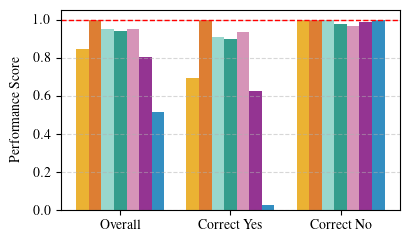

In [50]:
performance_scores = plot_summary_scores(df_dict_bystander, df_dict_busy, df_dict_specy, df_dict_specy_reverse, family_colors)

### Comparison with MMLU-Pro Benchmark

In [7]:
mmlu_scores = {'ministral14': np.float64(0.693),
 'ministral8': np.float64(0.642),
 'qwen8': np.float64(0.743),
 'qwen14': np.float64(0.774),
 'gemma12': np.float64(0.595),
 'gemma27': np.float64(0.669),
 'llama8': np.float64(0.476)}

In [8]:
benchmark_scores = {}

for model in performance_scores:

    benchmark_scores[model] = performance_scores[model]["Overall"]

benchmark_scores

{'gemma12': np.float64(0.84746913119295),
 'gemma27': np.float64(0.9997220504715445),
 'qwen8': np.float64(0.9523274757011443),
 'qwen14': np.float64(0.9374464514306281),
 'ministral8': np.float64(0.9488542949912879),
 'ministral14': np.float64(0.8051448779356021),
 'llama8': np.float64(0.5139023619053205)}

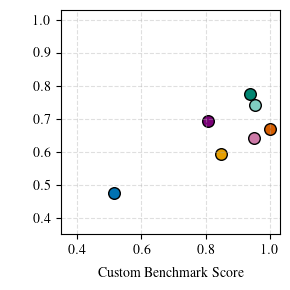

In [20]:
plt.figure(figsize=(HALF_WIDTH, HALF_WIDTH))

for model in benchmark_scores:
    plt.scatter(
        benchmark_scores[model],
        mmlu_scores[model],
        s=70,
        color=family_colors.get(model, "gray"),
        edgecolor="black",
        linewidth=1
    )
    
plt.xlabel("Custom Benchmark Score", fontsize=10,  labelpad = 8)
plt.ylabel("MMLU-Pro", fontsize=10, labelpad = 8, color = "white")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.ylim(0.35, 1.03)
plt.xlim(0.35, 1.03)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("plots/benchmark/benchmark_comparisons_shared_task.pdf", bbox_inches='tight')
plt.show()



In [36]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr

models = sorted(benchmark_scores.keys())  

# Extract aligned values
vals1 = [mmlu_scores[m] for m in models]
vals2 = [benchmark_scores[m] for m in models]

# Compute rank correlation
corr, pval = spearmanr(vals1, vals2)

print("Spearman correlation:", corr)
print("p-value:", pval)

# Compute normal correlation
corr, pval = pearsonr(vals1, vals2)

print("Pearson correlation:", corr)
print("p-value:", pval)

Spearman correlation: 0.42857142857142866
p-value: 0.3373683110858243
Pearson correlation: 0.796410959203217
p-value: 0.03208127990781378
